<a href="https://colab.research.google.com/github/MuhammadSahlanHabibi/Deteksi-Kaganga-CNN-Custom-dan-MobileNetV2/blob/main/Kaganga_Detection_Komering_Ulu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔡 Deteksi Tulisan Kaganga — Aksara Komering Ulu
**Tugas Mata Kuliah Computer Vision**

---
**Pendekatan:** Transfer Learning (MobileNetV2) + CNN Custom (perbandingan)  
**Dataset:** dataset komering ulu.zip (Google Drive)  
**Metrik Evaluasi:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix

---

## 1️⃣ Setup & Mount Google Drive

In [ ]:
# Install library tambahan jika diperlukan
!pip install -q tensorflow matplotlib seaborn scikit-learn pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive berhasil di-mount")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive berhasil di-mount


In [ ]:
import zipfile
import os

# Path file zip di Google Drive (Sudah disesuaikan ke folder kamu)
zip_path = '/content/drive/MyDrive/COMVIS CNN/dataset komering ulu.zip'
extract_path = '/content/dataset_kaganga'

# PAKSA EKSTRAK DATASET (Menghilangkan bypass 'if' agar folder kosong terisi kembali)
print("⏳ Sedang mengekstrak dataset, mohon tunggu sebentar...")
if not os.path.exists(extract_path):
    os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f"✅ Dataset berhasil diekstrak ke: {extract_path}")

# Tampilkan struktur folder
print("\n📁 Struktur Dataset:")
for root, dirs, files in os.walk(extract_path):
    level = root.replace(extract_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')
        if len(files) > 3:
            print(f'{subindent}... ({len(files)} files total)')

⏳ Sedang mengekstrak dataset, mohon tunggu sebentar...
✅ Dataset berhasil diekstrak ke: /content/dataset_kaganga

📁 Struktur Dataset:
dataset_kaganga/
  aksara/
    nto/
    lu/
    bar/
    gi/
    mpan/
    kan/
    dah/
    s/
    yu/
    rhau ghau/
    nyan/
    ye/
    rar/
    nyu/
    wai/
    yah/
    mpa/
    ncu/
    njai/
    pe/
    rah/
    hau/
    l/
    tan/
    ngga/
    mbu/
    ndo/
    mbau/
    hai/
    njan/
    wang/
    nyau/
    ndar/
    ngkar/
    gang/
    di/
    nti/
    han/
    ro/
    tang/
    nang/
    mar/
    dar/
    nj/
    ca/
    lau/
    ngi/
    ne/
    ndah/
    bo/
    ha/
    wu/
    tar/
    hang/
    ba/
    sai/
    so/
    rhe ghe/
    hi/
    ntau/
    ndi/
    gai/
    cah/
    nt/
    ngau/
    lai/
    nce/
    cau/
    nggau/
    wau/
    po/
    tu/
    ngge/
    se/
    mbah/
    pu/
    dan/
    ngai/
    pa/
    h/
    gah/
    a`/
    ai/
    kau/
    jan/
    ri/
    cu/
    rhan ghan/
    ku/
    c/
    rang/
    nda/
    ma

## 2️⃣ Import Library & Konfigurasi

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
from sklearn.model_selection import train_test_split

from PIL import Image
from pathlib import Path
import glob

# Cek GPU
print("TensorFlow version:", tf.__version__)
print("GPU tersedia:", len(tf.config.list_physical_devices('GPU')) > 0)
if tf.config.list_physical_devices('GPU'):
    print("GPU:", tf.config.list_physical_devices('GPU'))
else:
    print("⚠️ Tidak ada GPU — gunakan Runtime > Change runtime type > GPU")

# Set seed untuk reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ==================== KONFIGURASI ====================
IMG_SIZE     = 128         # Ukuran gambar (128x128 pixel)
BATCH_SIZE   = 32          # Batch size
EPOCHS_CNN   = 25          # Epoch CNN Custom
EPOCHS_TL    = 20          # Epoch Transfer Learning (fine-tune)
LR           = 1e-3        # Learning rate
VAL_SPLIT    = 0.15        # 15% validasi
TEST_SPLIT   = 0.15        # 15% test
# ======================================================
print("\n⚙️ Konfigurasi:")
print(f"  IMG_SIZE   : {IMG_SIZE}x{IMG_SIZE}")
print(f"  BATCH_SIZE : {BATCH_SIZE}")
print(f"  EPOCHS CNN : {EPOCHS_CNN}")
print(f"  EPOCHS TL  : {EPOCHS_TL}")

TensorFlow version: 2.20.0
GPU tersedia: True
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

⚙️ Konfigurasi:
  IMG_SIZE   : 128x128
  BATCH_SIZE : 32
  EPOCHS CNN : 25
  EPOCHS TL  : 20


## 3️⃣ Eksplorasi Dataset (EDA)

In [ ]:
# Auto-detect root folder dataset (folder yang mengandung subfolder kelas)
def find_dataset_root(base_path):
    """Temukan folder yang mengandung subfolder kelas gambar"""
    for root, dirs, files in os.walk(base_path):
        # Folder yang punya subfolder dan di dalamnya ada gambar
        if dirs:
            for d in dirs:
                sub = os.path.join(root, d)
                imgs = glob.glob(os.path.join(sub, '*.png')) + \
                       glob.glob(os.path.join(sub, '*.jpg')) + \
                       glob.glob(os.path.join(sub, '*.jpeg'))
                if imgs:
                    return root
    return base_path

DATASET_ROOT = find_dataset_root(extract_path)
print(f"📂 Dataset root: {DATASET_ROOT}")

# Hitung jumlah data per kelas
class_names = sorted([d for d in os.listdir(DATASET_ROOT)
                       if os.path.isdir(os.path.join(DATASET_ROOT, d))])
NUM_CLASSES = len(class_names)

class_counts = {}
all_image_paths = []
all_labels = []

for cls in class_names:
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.png')) + \
           glob.glob(os.path.join(cls_path, '*.jpg')) + \
           glob.glob(os.path.join(cls_path, '*.jpeg'))
    class_counts[cls] = len(imgs)
    all_image_paths.extend(imgs)
    all_labels.extend([class_names.index(cls)] * len(imgs))

TOTAL_IMAGES = len(all_image_paths)
print(f"\n📊 Ringkasan Dataset:")
print(f"  Total Kelas  : {NUM_CLASSES}")
print(f"  Total Gambar : {TOTAL_IMAGES}")
print(f"\n  Distribusi per kelas:")
for cls, cnt in class_counts.items():
    bar = '█' * (cnt // max(1, max(class_counts.values()) // 30))
    print(f"  {cls:<20} {cnt:>4} gambar  {bar}")

📂 Dataset root: /content/dataset_kaganga/aksara

📊 Ringkasan Dataset:
  Total Kelas  : 336
  Total Gambar : 21150

  Distribusi per kelas:
  a                      51 gambar  ██████████
  a`                     49 gambar  █████████
  ah                     49 gambar  █████████
  ai                     48 gambar  █████████
  an                     48 gambar  █████████
  ang                    48 gambar  █████████
  ar                    141 gambar  ████████████████████████████
  au                     48 gambar  █████████
  b                      42 gambar  ████████
  ba                     43 gambar  ████████
  bah                    43 gambar  ████████
  bai                    43 gambar  ████████
  ban                    43 gambar  ████████
  bang                   43 gambar  ████████
  bar                   129 gambar  █████████████████████████
  bau                    43 gambar  ████████
  be                     86 gambar  █████████████████
  bi                     86 gambar  ██████

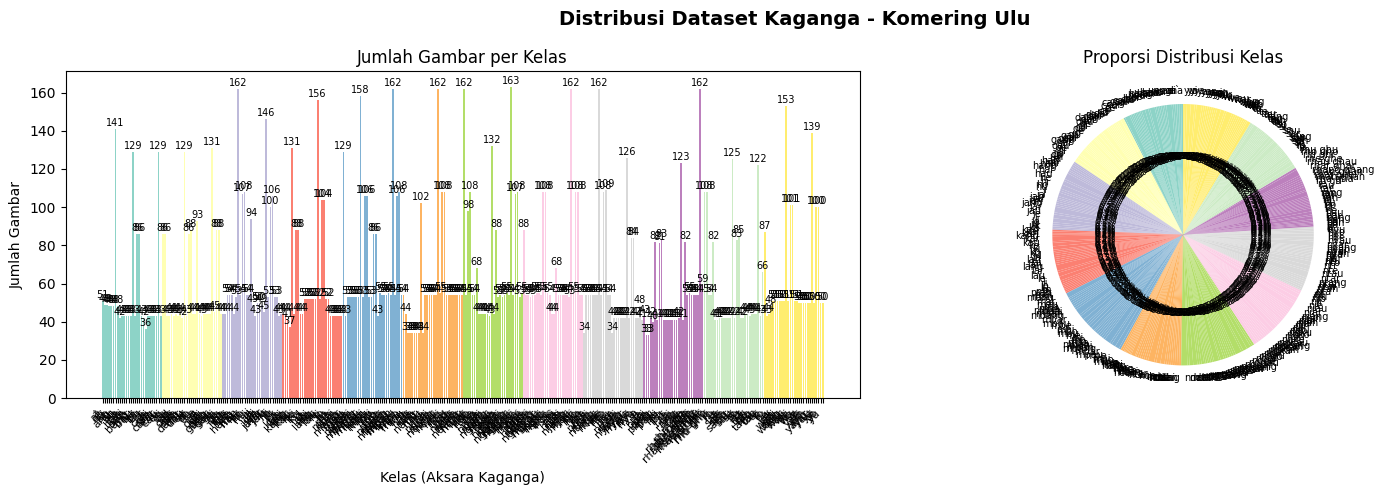

✅ Grafik distribusi disimpan


In [ ]:
# Visualisasi distribusi kelas
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribusi Dataset Kaganga - Komering Ulu', fontsize=14, fontweight='bold')

# Bar chart
colors = plt.cm.Set3(np.linspace(0, 1, NUM_CLASSES))
bars = axes[0].bar(range(NUM_CLASSES), list(class_counts.values()), color=colors)
axes[0].set_xticks(range(NUM_CLASSES))
axes[0].set_xticklabels(list(class_counts.keys()), rotation=45, ha='right', fontsize=8)
axes[0].set_title('Jumlah Gambar per Kelas')
axes[0].set_ylabel('Jumlah Gambar')
axes[0].set_xlabel('Kelas (Aksara Kaganga)')
for bar, cnt in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 str(cnt), ha='center', va='bottom', fontsize=7)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    list(class_counts.values()),
    labels=list(class_counts.keys()),
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
for text in texts:
    text.set_fontsize(7)
for autotext in autotexts:
    autotext.set_fontsize(6)
axes[1].set_title('Proporsi Distribusi Kelas')

plt.tight_layout()
plt.savefig('/content/distribusi_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafik distribusi disimpan")

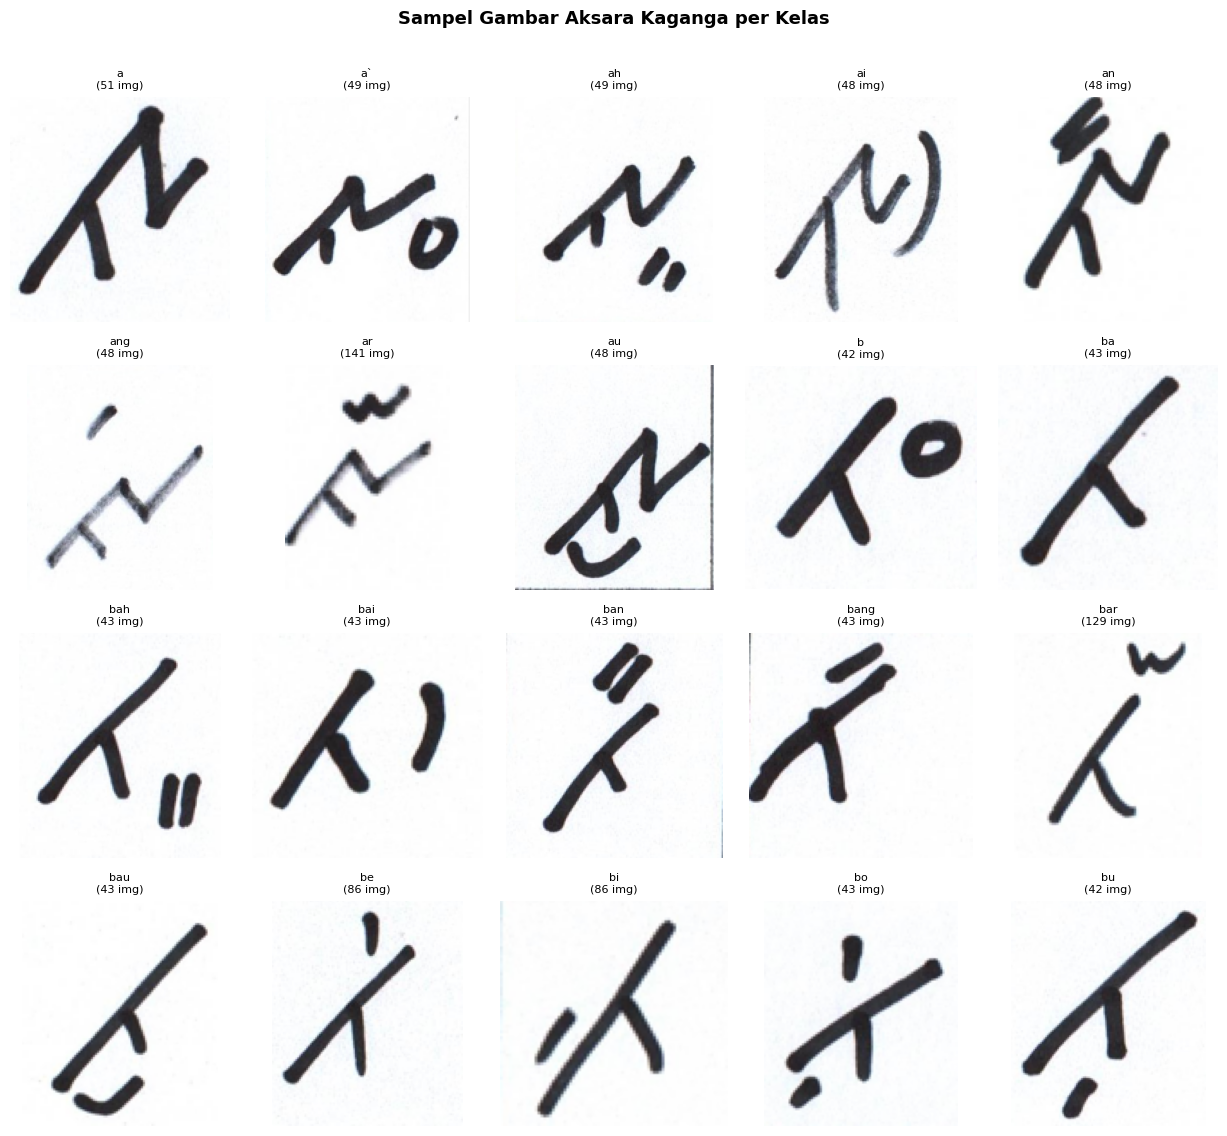

✅ Menampilkan 20 dari 336 kelas


In [ ]:
# Tampilkan sampel gambar per kelas
n_show = min(NUM_CLASSES, 20)  # Maksimal 20 kelas ditampilkan
cols = 5
rows = (n_show + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))
fig.suptitle('Sampel Gambar Aksara Kaganga per Kelas', fontsize=13, fontweight='bold', y=1.01)

axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes.flatten()

for i, cls in enumerate(class_names[:n_show]):
    cls_path = os.path.join(DATASET_ROOT, cls)
    imgs = glob.glob(os.path.join(cls_path, '*.png')) + \
           glob.glob(os.path.join(cls_path, '*.jpg'))
    if imgs:
        img = Image.open(imgs[0]).convert('RGB')
        axes[i].imshow(img)
        axes[i].set_title(f'{cls}\n({class_counts[cls]} img)', fontsize=8)
        axes[i].axis('off')

# Sembunyikan axes kosong
for j in range(n_show, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('/content/sampel_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Menampilkan {n_show} dari {NUM_CLASSES} kelas")

In [ ]:
# Analisis properti gambar (ukuran, mode warna)
sample_paths = all_image_paths[:min(100, TOTAL_IMAGES)]
widths, heights, modes = [], [], []

for p in sample_paths:
    try:
        img = Image.open(p)
        widths.append(img.width)
        heights.append(img.height)
        modes.append(img.mode)
    except:
        pass

print("📐 Analisis Properti Gambar (dari 100 sampel):")
print(f"  Lebar   : min={min(widths)}, max={max(widths)}, rata-rata={int(np.mean(widths))}")
print(f"  Tinggi  : min={min(heights)}, max={max(heights)}, rata-rata={int(np.mean(heights))}")
print(f"  Mode    : {set(modes)}")
print(f"\n  → Semua gambar akan di-resize ke {IMG_SIZE}x{IMG_SIZE} untuk training")

📐 Analisis Properti Gambar (dari 100 sampel):
  Lebar   : min=57, max=329, rata-rata=159
  Tinggi  : min=50, max=320, rata-rata=158
  Mode    : {'RGB', 'RGBA'}

  → Semua gambar akan di-resize ke 128x128 untuk training


## 4️⃣ Preprocessing & Data Augmentation

In [ ]:
# Split data: train / val / test
# Stratified split agar distribusi kelas merata
from sklearn.model_selection import train_test_split

X = np.array(all_image_paths)
y = np.array(all_labels)

# Split test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=TEST_SPLIT, random_state=SEED, stratify=y
)
# Split val dari sisa
val_ratio_adj = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_ratio_adj, random_state=SEED, stratify=y_temp
)

print("📦 Pembagian Dataset:")
print(f"  Train : {len(X_train)} gambar ({len(X_train)/TOTAL_IMAGES*100:.1f}%)")
print(f"  Val   : {len(X_val)} gambar ({len(X_val)/TOTAL_IMAGES*100:.1f}%)")
print(f"  Test  : {len(X_test)} gambar ({len(X_test)/TOTAL_IMAGES*100:.1f}%)")

📦 Pembagian Dataset:
  Train : 14804 gambar (70.0%)
  Val   : 3173 gambar (15.0%)
  Test  : 3173 gambar (15.0%)


In [ ]:
# Fungsi load dan preprocess gambar
def load_and_preprocess(path, label, augment=False):
    """Load gambar, resize, normalize, dan augmentasi opsional"""
    img_raw  = tf.io.read_file(path)
    img      = tf.image.decode_png(img_raw, channels=3)
    img      = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img      = tf.cast(img, tf.float32) / 255.0  # Normalisasi [0,1]

    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        # Random rotation kecil via shear
        img = tf.image.random_crop(
            tf.image.resize_with_pad(img, IMG_SIZE+10, IMG_SIZE+10),
            [IMG_SIZE, IMG_SIZE, 3]
        )
    return img, label

# Buat tf.data.Dataset
def make_dataset(paths, labels, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(
        lambda p, l: load_and_preprocess(p, l, augment=augment),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment=True, shuffle=True)
val_ds   = make_dataset(X_val, y_val, augment=False, shuffle=False)
test_ds  = make_dataset(X_test, y_test, augment=False, shuffle=False)

print("✅ Dataset pipeline siap")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val batches   : {len(val_ds)}")
print(f"  Test batches  : {len(test_ds)}")

✅ Dataset pipeline siap
  Train batches : 463
  Val batches   : 100
  Test batches  : 100


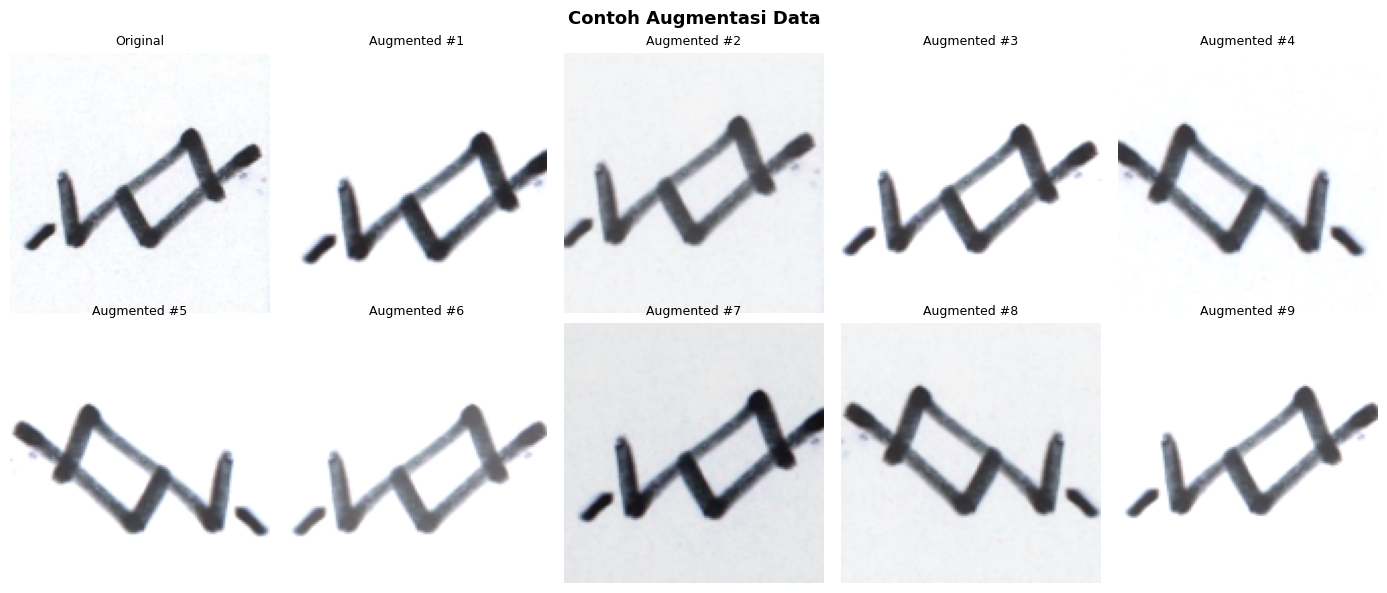

In [ ]:
# Visualisasi efek augmentasi
original_img = load_and_preprocess(X_train[0], y_train[0], augment=False)[0].numpy()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Contoh Augmentasi Data', fontsize=13, fontweight='bold')

axes[0, 0].imshow(original_img)
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')

for i in range(1, 10):
    aug_img = load_and_preprocess(X_train[0], y_train[0], augment=True)[0].numpy()
    r, c = divmod(i, 5)
    axes[r][c].imshow(aug_img)
    axes[r][c].set_title(f'Augmented #{i}', fontsize=9)
    axes[r][c].axis('off')

plt.tight_layout()
plt.savefig('/content/augmentasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 5️⃣ Model 1 — CNN Custom (Baseline)

In [ ]:
def build_cnn_custom(num_classes, img_size=IMG_SIZE):
    """
    CNN Custom dengan arsitektur:
    Conv → MaxPool → Conv → MaxPool → Conv → MaxPool → Dense → Output
    """
    model = models.Sequential([
        # Input
        layers.Input(shape=(img_size, img_size, 3)),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        # Classifier
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ], name='CNN_Custom')
    return model

cnn_model = build_cnn_custom(NUM_CLASSES)
cnn_model.summary()

# Compile
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

total_params = cnn_model.count_params()
print(f"\n📊 Total parameter CNN Custom: {total_params:,}")

Model: "CNN_Custom"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,32

 Total params: 935,408 (3.57 MB)

 Trainable params: 933,424 (3.56 MB)

 Non-trainable params: 1,984 (7.75 KB)


📊 Total parameter CNN Custom: 935,408


In [ ]:
# Callbacks
cnn_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        '/content/cnn_best.h5', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print("🚀 Mulai training CNN Custom...")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_CNN,
    callbacks=cnn_callbacks,
    verbose=1
)
print("✅ Training CNN Custom selesai!")

🚀 Mulai training CNN Custom...
Epoch 1/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.0056 - loss: 6.3250

463/463 ━━━━━━━━━━━━━━━━━━━━ 62s 89ms/step - accuracy: 0.0065 - loss: 6.1324 - val_accuracy: 0.0069 - val_loss: 5.7284 - learning_rate: 0.0010
Epoch 2/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.0095 - loss: 5.7006

463/463 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.0132 - loss: 5.6168 - val_accuracy: 0.0132 - val_loss: 5.4660 - learning_rate: 0.0010
Epoch 3/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.0295 - loss: 5.2228 - val_accuracy: 0.0063 - val_loss: 10.9717 - learning_rate: 0.0010
Epoch 4/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.0651 - loss: 4.6910

463/463 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.0759 - loss: 4.4853 - val_accuracy: 0.0205 - val_loss: 5.2704 - learning_rate: 0.0010
Epoch 5/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.1442 - loss: 3.7711

463/463 ━━━━━━━━━━━━━━━━━━━━ 28s 60ms/step - accuracy: 0.1702 - loss: 3.5577 - val_accuracy: 0.2893 - val_loss: 2.9562 - learning_rate: 0.0010
Epoch 6/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2597 - loss: 2.9611

...

463/463 ━━━━━━━━━━━━━━━━━━━━ 24s 53ms/step - accuracy: 0.7114 - loss: 0.9861 - val_accuracy: 0.7888 - val_loss: 0.7405 - learning_rate: 0.0010
Epoch 14/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7383 - loss: 0.8671

463/463 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.7322 - loss: 0.8949 - val_accuracy: 0.8260 - val_loss: 0.6315 - learning_rate: 0.0010
Epoch 15/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.7407 - loss: 0.8476 - val_accuracy: 0.5254 - val_loss: 1.8374 - learning_rate: 0.0010
Epoch 16/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 44s 61ms/step - accuracy: 0.7547 - loss: 0.7970 - val_accuracy: 0.0057 - val_loss: 13.3670 - learning_rate: 0.0010
Epoch 17/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.7762 - loss: 0.7239
Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
463/463 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.7728 - loss: 0.7420 - val_accuracy: 0.5418 - val_loss: 1.8135 - learning_rate: 0.0010
Epoch 18/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8099 - loss: 0.6023

463/463 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.8136 - loss: 0.5968 - val_accuracy: 0.8985 - val_loss: 0.3923 - learning_rate: 5.0000e-04
Epoch 19/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 26s 55ms/step - accuracy: 0.8330 - loss: 0.5364 - val_accuracy: 0.7554 - val_loss: 0.8838 - learning_rate: 5.0000e-04
Epoch 20/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.8403 - loss: 0.5144 - val_accuracy: 0.0274 - val_loss: 10.3530 - learning_rate: 5.0000e-04
Epoch 21/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8490 - loss: 0.4856

463/463 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.8483 - loss: 0.4907 - val_accuracy: 0.9231 - val_loss: 0.3194 - learning_rate: 5.0000e-04
Epoch 22/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8557 - loss: 0.4564

463/463 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.8554 - loss: 0.4643 - val_accuracy: 0.9281 - val_loss: 0.2820 - learning_rate: 5.0000e-04
Epoch 23/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.8565 - loss: 0.4612 - val_accuracy: 0.4951 - val_loss: 1.9731 - learning_rate: 5.0000e-04
Epoch 24/25
463/463 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.8537 - loss: 0.4603 - val_accuracy: 0.2165 - val_loss: 4.0596 - learning_rate: 5.0000e-04
Epoch 25/25
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.8663 - loss: 0.4045
Epoch 25: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
463/463 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.8640 - loss: 0.4151 - val_accuracy: 0.1034 - val_loss: 5.5902 - learning_rate: 5.0000e-04
Restoring model weights from the end of the best epoch: 22.
✅ Training CNN Custom selesai!


## 6️⃣ Model 2 — Transfer Learning (MobileNetV2)

In [ ]:
def build_mobilenetv2(num_classes, img_size=IMG_SIZE):
    """
    Transfer Learning menggunakan MobileNetV2 pre-trained ImageNet
    Strategi: Freeze base → Train head → Fine-tune top layers
    """
    # Load pre-trained MobileNetV2 tanpa classifier atas
    base_model = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    # Freeze semua layer base
    base_model.trainable = False

    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='MobileNetV2_Transfer')
    return model, base_model

tl_model, base_model = build_mobilenetv2(NUM_CLASSES)
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Hitung frozen vs trainable params
trainable = sum([np.prod(v.shape) for v in tl_model.trainable_variables])
non_trainable = sum([np.prod(v.shape) for v in tl_model.non_trainable_variables])
print(f"📊 MobileNetV2:")
print(f"  Total params      : {trainable + non_trainable:,}")
print(f"  Trainable params  : {trainable:,}")
print(f"  Frozen params     : {non_trainable:,}")
tl_model.summary()

📊 MobileNetV2:
  Total params      : 3,133,588
  Trainable params  : 874,576
  Frozen params     : 2,259,012


Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 336)            │        86,352 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,133,584 (11.95 MB)

 Trainable params: 874,576 (3.34 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [ ]:
# --- PHASE 1: Train hanya classifier head ---
tl_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
    ),
    callbacks.ModelCheckpoint(
        '/content/tl_best.h5', monitor='val_accuracy',
        save_best_only=True, verbose=0
    )
]

print("🚀 Phase 1: Training classifier head (base frozen)...")
history_tl_phase1 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=tl_callbacks,
    verbose=1
)
print("✅ Phase 1 selesai!")

🚀 Phase 1: Training classifier head (base frozen)...
Epoch 1/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0659 - loss: 5.2542

463/463 ━━━━━━━━━━━━━━━━━━━━ 69s 106ms/step - accuracy: 0.1194 - loss: 4.4182 - val_accuracy: 0.2994 - val_loss: 2.7609 - learning_rate: 0.0010
Epoch 2/10
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2774 - loss: 2.7836

463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.2992 - loss: 2.6645 - val_accuracy: 0.4274 - val_loss: 2.0598 - learning_rate: 0.0010
Epoch 3/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3952 - loss: 2.1641

463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.3997 - loss: 2.1481 - val_accuracy: 0.4844 - val_loss: 1.7770 - learning_rate: 0.0010
Epoch 4/10
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4523 - loss: 1.9007

463/463 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.4497 - loss: 1.8975 - val_accuracy: 0.5153 - val_loss: 1.6428 - learning_rate: 0.0010
Epoch 5/10
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4966 - loss: 1.7109

463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.4975 - loss: 1.7175 - val_accuracy: 0.5604 - val_loss: 1.4837 - learning_rate: 0.0010
Epoch 6/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.5213 - loss: 1.6164 - val_accuracy: 0.5556 - val_loss: 1.5112 - learning_rate: 0.0010
Epoch 7/10
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5573 - loss: 1.5043

463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.5469 - loss: 1.5305 - val_accuracy: 0.5890 - val_loss: 1.4315 - learning_rate: 0.0010
Epoch 8/10
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5698 - loss: 1.4200

463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.5623 - loss: 1.4612 - val_accuracy: 0.5988 - val_loss: 1.3412 - learning_rate: 0.0010
Epoch 9/10
463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.5771 - loss: 1.4130 - val_accuracy: 0.5887 - val_loss: 1.3614 - learning_rate: 0.0010
Epoch 10/10
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5950 - loss: 1.3193

463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.5911 - loss: 1.3480 - val_accuracy: 0.5994 - val_loss: 1.3334 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.
✅ Phase 1 selesai!


In [ ]:
# --- PHASE 2: Fine-tune — unfreeze 50 layer terakhir base model ---
base_model.trainable = True

# Freeze layer-layer awal, unfreeze 50 layer terakhir
fine_tune_from = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# Compile ulang dengan LR lebih kecil
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=LR / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

trainable_now = sum([np.prod(v.shape) for v in tl_model.trainable_variables])
print(f"📊 Fine-tune: {trainable_now:,} parameter trainable")
print("\n🚀 Phase 2: Fine-tuning...")

history_tl_phase2 = tl_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TL,
    callbacks=tl_callbacks,
    verbose=1
)
print("✅ Fine-tuning selesai!")

📊 Fine-tune: 2,729,680 parameter trainable

🚀 Phase 2: Fine-tuning...
Epoch 1/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 67s 89ms/step - accuracy: 0.4184 - loss: 2.4031 - val_accuracy: 0.0895 - val_loss: 7.1573 - learning_rate: 1.0000e-04
Epoch 2/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step - accuracy: 0.6471 - loss: 1.1431 - val_accuracy: 0.1453 - val_loss: 4.8428 - learning_rate: 1.0000e-04
Epoch 3/20
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7313 - loss: 0.8561
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
463/463 ━━━━━━━━━━━━━━━━━━━━ 19s 41ms/step - accuracy: 0.7444 - loss: 0.8280 - val_accuracy: 0.2792 - val_loss: 3.0831 - learning_rate: 1.0000e-04
Epoch 4/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 24s 49ms/step - accuracy: 0.8036 - loss: 0.6245 - val_accuracy: 0.5506 - val_loss: 1.5193 - learning_rate: 5.0000e-05
Epoch 5/20
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8267 - loss: 0.5565

463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 44ms/step - accuracy: 0.8289 - loss: 0.5433 - val_accuracy: 0.8014 - val_loss: 0.6472 - learning_rate: 5.0000e-05
Epoch 6/20
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8447 - loss: 0.4953

463/463 ━━━━━━━━━━━━━━━━━━━━ 23s 49ms/step - accuracy: 0.8440 - loss: 0.4888 - val_accuracy: 0.8352 - val_loss: 0.5560 - learning_rate: 5.0000e-05
Epoch 7/20
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8583 - loss: 0.4476

463/463 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.8581 - loss: 0.4527 - val_accuracy: 0.8594 - val_loss: 0.4880 - learning_rate: 5.0000e-05
Epoch 8/20
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8679 - loss: 0.4141

463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.8740 - loss: 0.4054 - val_accuracy: 0.8843 - val_loss: 0.4120 - learning_rate: 5.0000e-05
Epoch 9/20
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8825 - loss: 0.3641

...

463/463 ━━━━━━━━━━━━━━━━━━━━ 23s 47ms/step - accuracy: 0.9148 - loss: 0.2705 - val_accuracy: 0.9159 - val_loss: 0.3241 - learning_rate: 5.0000e-05
Epoch 15/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 42s 50ms/step - accuracy: 0.9248 - loss: 0.2447 - val_accuracy: 0.9121 - val_loss: 0.3288 - learning_rate: 5.0000e-05
Epoch 16/20
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9321 - loss: 0.2129

463/463 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.9329 - loss: 0.2168 - val_accuracy: 0.9199 - val_loss: 0.3070 - learning_rate: 5.0000e-05
Epoch 17/20
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9370 - loss: 0.2121

463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9371 - loss: 0.2080 - val_accuracy: 0.9259 - val_loss: 0.3002 - learning_rate: 5.0000e-05
Epoch 18/20
462/463 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9434 - loss: 0.1861

463/463 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - accuracy: 0.9397 - loss: 0.1937 - val_accuracy: 0.9351 - val_loss: 0.2642 - learning_rate: 5.0000e-05
Epoch 19/20
463/463 ━━━━━━━━━━━━━━━━━━━━ 22s 46ms/step - accuracy: 0.9394 - loss: 0.1938 - val_accuracy: 0.9278 - val_loss: 0.2761 - learning_rate: 5.0000e-05
Epoch 20/20
461/463 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9431 - loss: 0.1791

463/463 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9437 - loss: 0.1790 - val_accuracy: 0.9363 - val_loss: 0.2496 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 20.
✅ Fine-tuning selesai!


In [ ]:
# Gabungkan history phase 1 + 2 untuk TL
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history[k]
    return merged

history_tl_merged = merge_histories(history_tl_phase1, history_tl_phase2)
print(f"Total epoch TL: {len(history_tl_merged['accuracy'])}")

Total epoch TL: 30


## 7️⃣ Visualisasi Kurva Training

CNN Custom


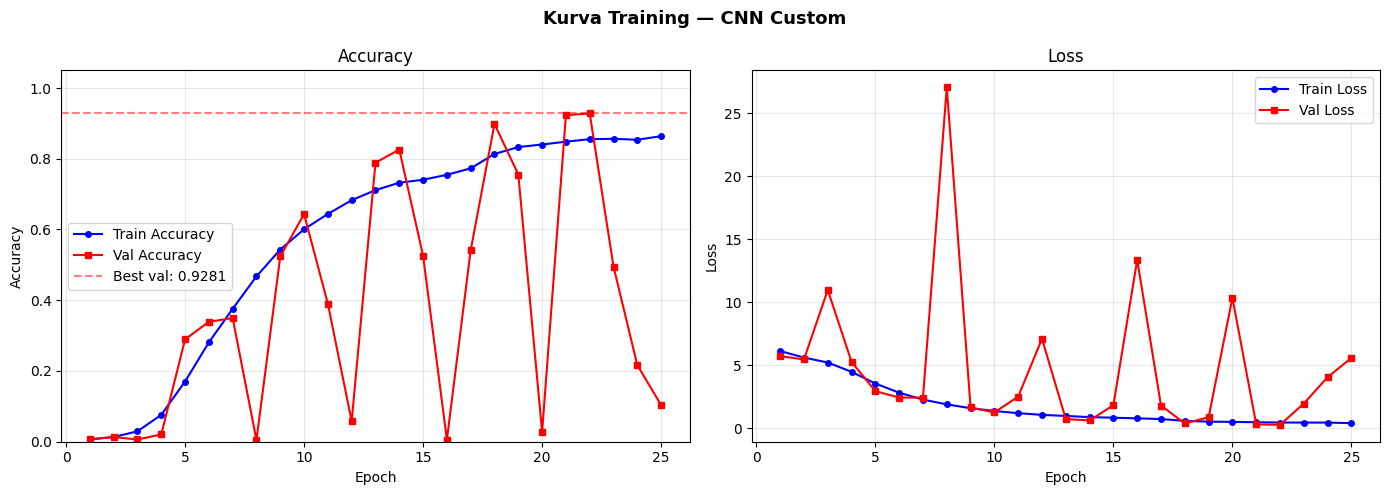

  Best Val Accuracy: 0.9281 (Epoch 22)
Transfer Learning (MobileNetV2)


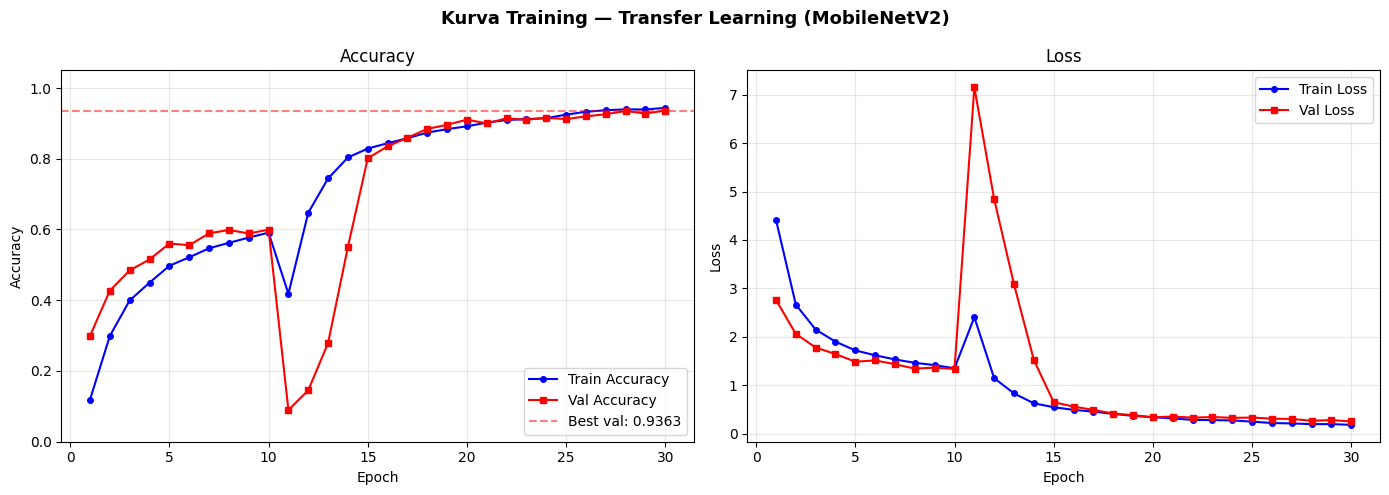

  Best Val Accuracy: 0.9363 (Epoch 30)


In [ ]:
def plot_training_curves(history_dict, title, save_path=None):
    """Plot accuracy dan loss training vs validation"""
    acc     = history_dict['accuracy']
    val_acc = history_dict['val_accuracy']
    loss    = history_dict['loss']
    val_loss= history_dict['val_loss']
    epochs  = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Kurva Training — {title}', fontsize=13, fontweight='bold')

    # Accuracy
    ax1.plot(epochs, acc,     'b-o', ms=4, label='Train Accuracy')
    ax1.plot(epochs, val_acc, 'r-s', ms=4, label='Val Accuracy')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.set_ylim([0, 1.05])
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=max(val_acc), color='r', linestyle='--', alpha=0.5,
                label=f'Best val: {max(val_acc):.4f}')
    ax1.legend()

    # Loss
    ax2.plot(epochs, loss,     'b-o', ms=4, label='Train Loss')
    ax2.plot(epochs, val_loss, 'r-s', ms=4, label='Val Loss')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    best_val_acc = max(val_acc)
    best_epoch   = val_acc.index(best_val_acc) + 1
    print(f"  Best Val Accuracy: {best_val_acc:.4f} (Epoch {best_epoch})")
    return best_val_acc

print("=" * 50)
print("CNN Custom")
print("=" * 50)
best_cnn = plot_training_curves(history_cnn.history, 'CNN Custom', '/content/training_cnn.png')

print("=" * 50)
print("Transfer Learning (MobileNetV2)")
print("=" * 50)
best_tl = plot_training_curves(history_tl_merged, 'Transfer Learning (MobileNetV2)', '/content/training_tl.png')

## 8️⃣ Evaluasi Model pada Test Set

In [ ]:
def evaluate_model(model, test_dataset, class_names, model_name):
    """Evaluasi lengkap: accuracy, precision, recall, F1, confusion matrix"""
    print(f"\n{'='*60}")
    print(f"  Evaluasi: {model_name}")
    print(f"{'='*60}")

    # Prediksi semua batch
    y_pred_list, y_true_list = [], []
    for imgs, labels in test_dataset:
        preds = model.predict(imgs, verbose=0)
        y_pred_list.extend(np.argmax(preds, axis=1))
        y_true_list.extend(labels.numpy())

    y_pred = np.array(y_pred_list)
    y_true = np.array(y_true_list)

    # Metrik utama
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    prec= precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n  Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")

    # Classification Report
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    return y_true, y_pred, acc, prec, rec, f1

# Evaluasi kedua model
y_true_cnn, y_pred_cnn, acc_cnn, prec_cnn, rec_cnn, f1_cnn = \
    evaluate_model(cnn_model, test_ds, class_names, 'CNN Custom')

y_true_tl, y_pred_tl, acc_tl, prec_tl, rec_tl, f1_tl = \
    evaluate_model(tl_model, test_ds, class_names, 'Transfer Learning (MobileNetV2)')


  Evaluasi: CNN Custom

  Accuracy  : 0.9332 (93.32%)
  Precision : 0.9383
  Recall    : 0.9332
  F1-Score  : 0.9307

  Classification Report:
              precision    recall  f1-score   support

           a       1.00      1.00      1.00         8
          a`       1.00      1.00      1.00         7
          ah       1.00      1.00      1.00         7
          ai       1.00      1.00      1.00         7
          an       1.00      0.86      0.92         7
         ang       1.00      1.00      1.00         7
          ar       0.95      1.00      0.98        21
          au       0.88      1.00      0.93         7
           b       1.00      1.00      1.00         6
          ba       1.00      1.00      1.00         6
         bah       1.00      1.00      1.00         6
         bai       0.86      1.00      0.92         6
         ban       1.00      0.71      0.83         7
        bang       0.88      1.00      0.93         7
         bar       1.00      1.00      1.00  

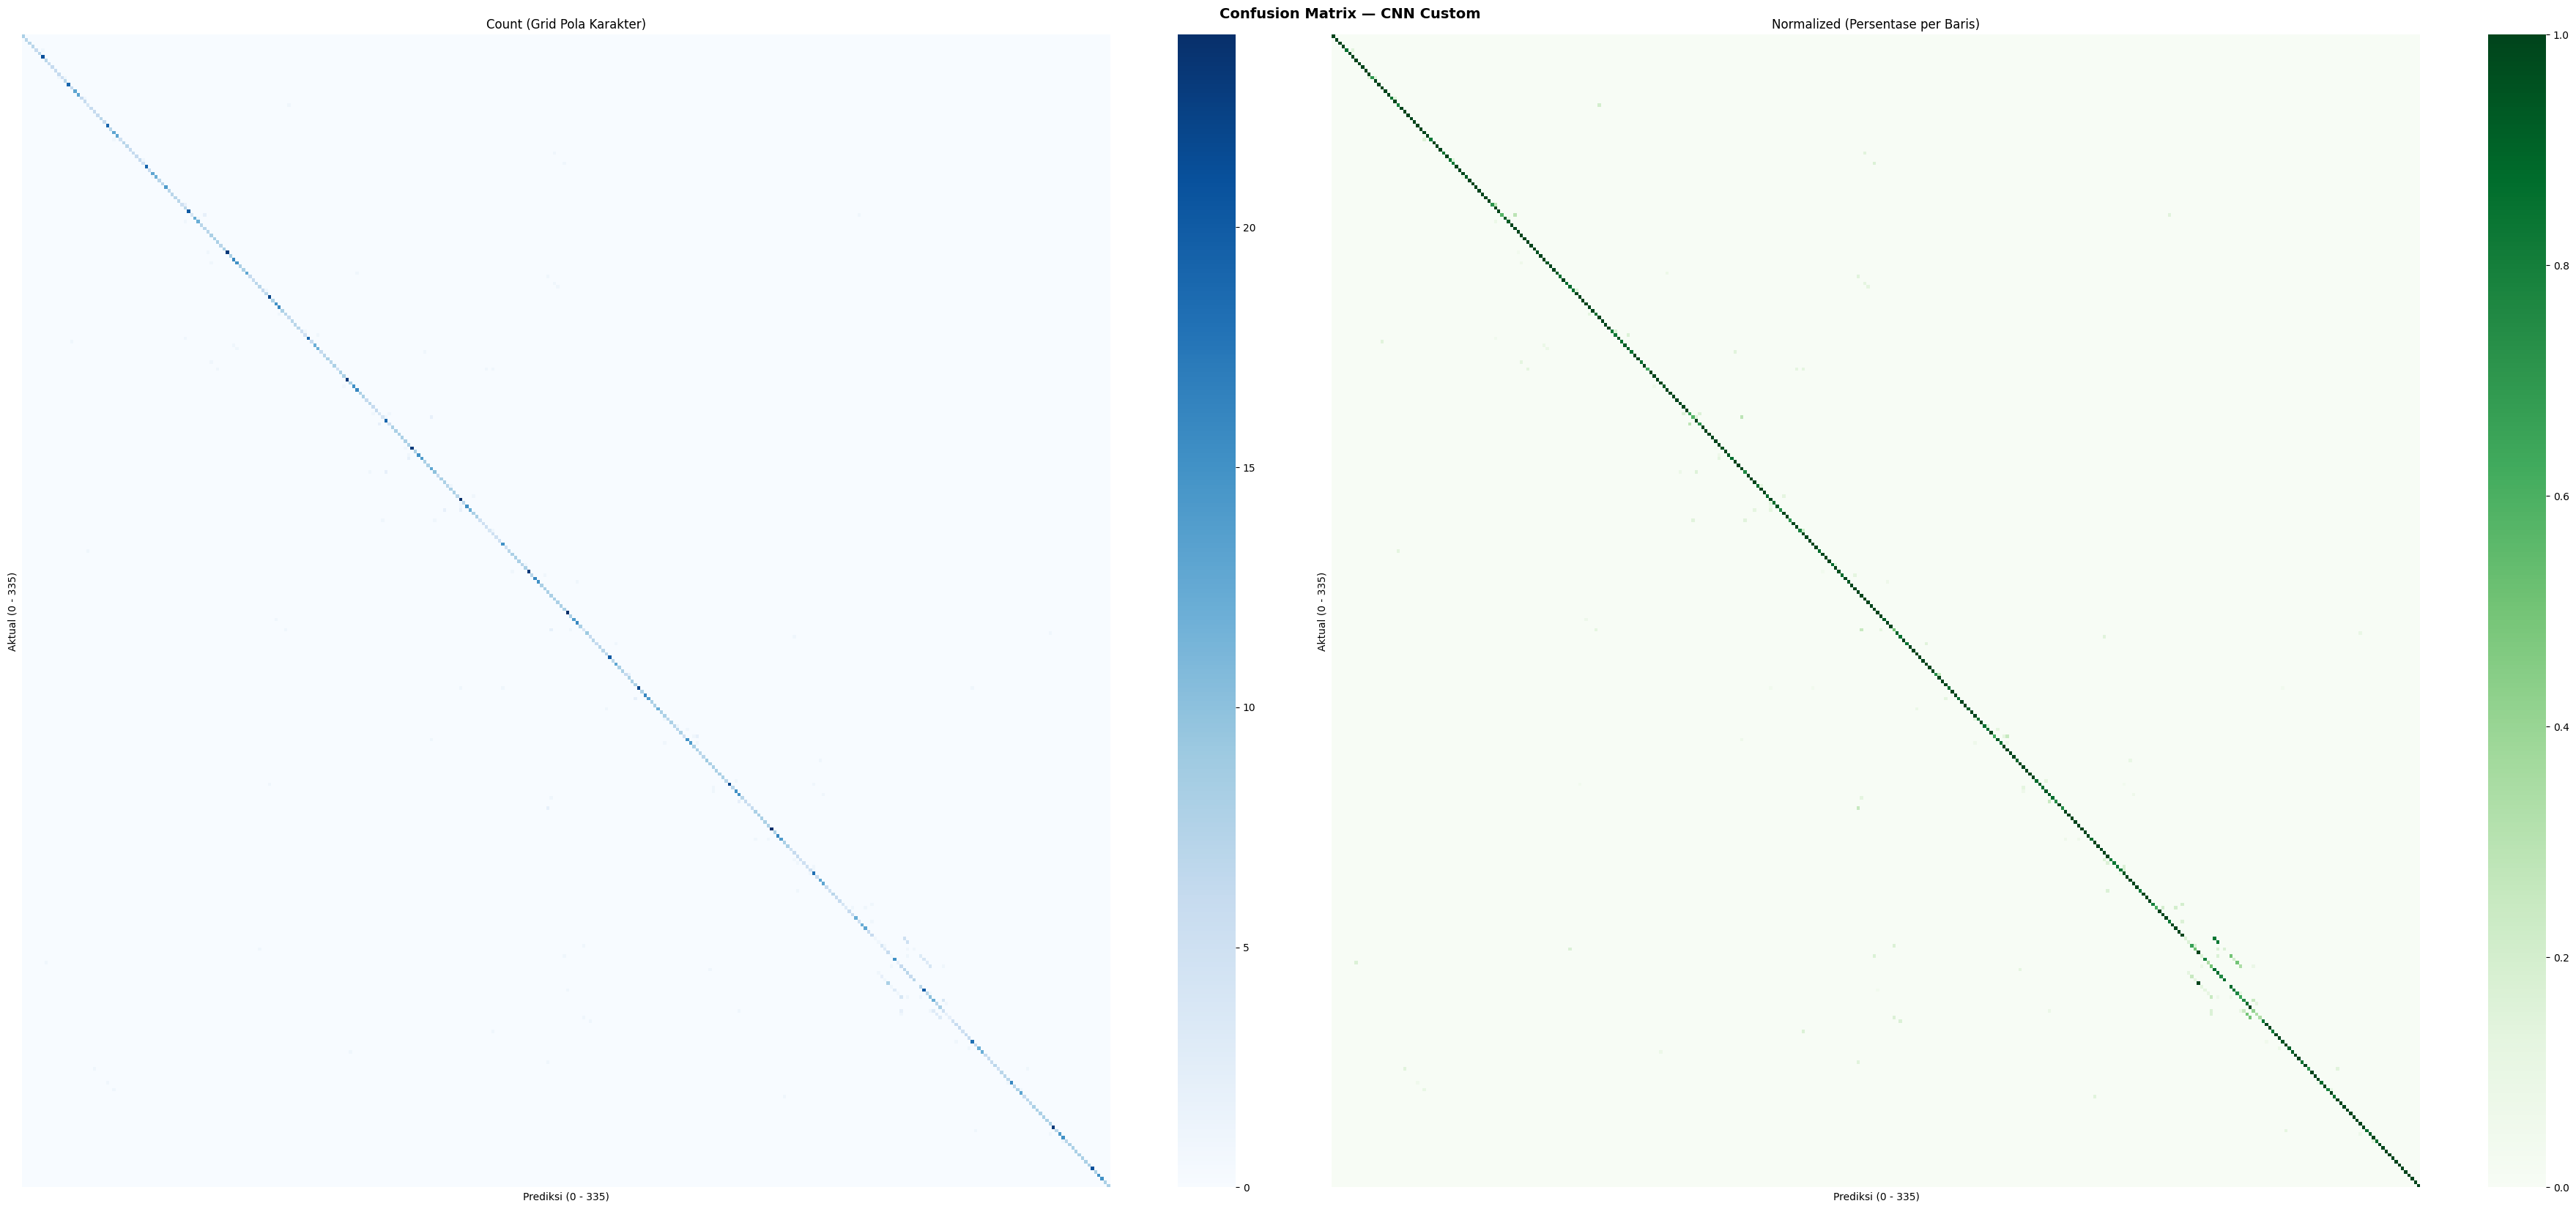

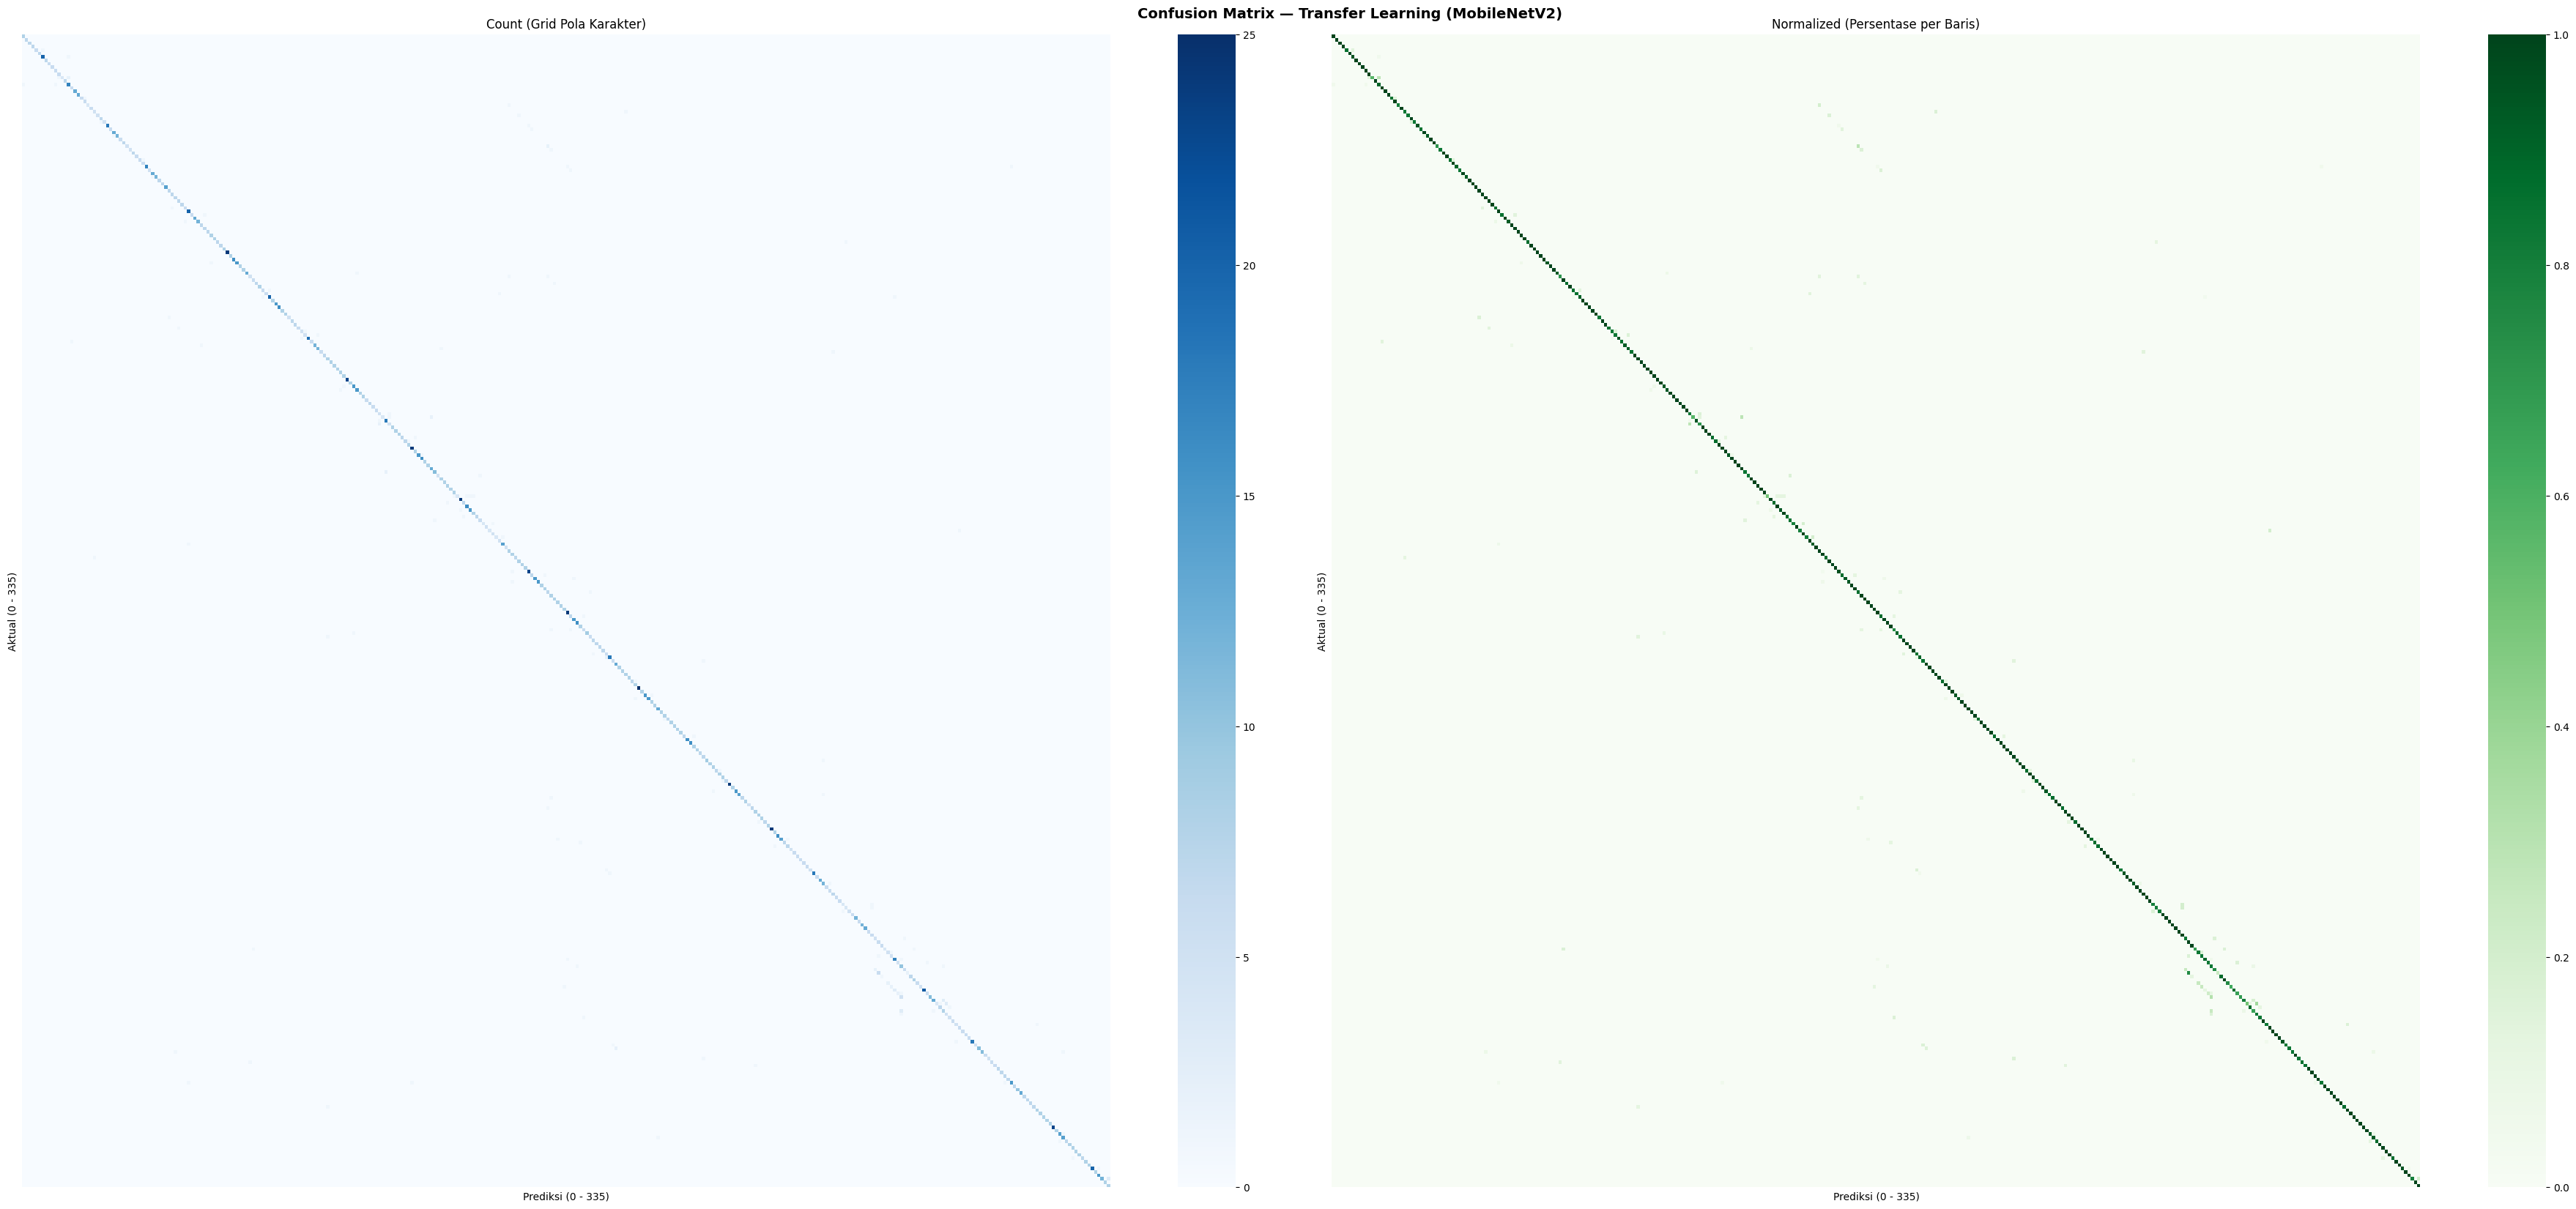

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    """Plot confusion matrix yang aman dan dioptimasi untuk ratusan kelas"""
    # 1. Paksa matriks agar selalu berukuran 336x336 sesuai jumlah total kelas
    num_classes = len(class_names)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

    # Antisipasi jika ada pembagian dengan nol (zero division) saat normalisasi
    row_sums = cm.sum(axis=1)[:, np.newaxis]
    cm_norm = np.divide(cm.astype('float'), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

    # 2. Batasi ukuran figsize maksimal di angka 20 agar tidak membuat RAM Colab meledak
    fig_size = min(20, max(10, num_classes * 0.05))
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(fig_size * 2.2, fig_size))
    fig.suptitle(f'Confusion Matrix — {title}', fontsize=14, fontweight='bold')

    # 3. Matikan annot, linewidths, dan label teks karena kotak terlalu padat (112.000+ sel)
    # Kita akan melihatnya sebagai grid warna global untuk mendeteksi pola error secara visual
    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=False, yticklabels=False,
                ax=ax1, cbar=True)
    ax1.set_title('Count (Grid Pola Karakter)')
    ax1.set_xlabel('Prediksi (0 - 335)')
    ax1.set_ylabel('Aktual (0 - 335)')

    sns.heatmap(cm_norm, annot=False, cmap='Greens',
                xticklabels=False, yticklabels=False,
                ax=ax2, cbar=True)
    ax2.set_title('Normalized (Persentase per Baris)')
    ax2.set_xlabel('Prediksi (0 - 335)')
    ax2.set_ylabel('Aktual (0 - 335)')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Panggil fungsi yang sudah diperbaiki
plot_confusion_matrix(y_true_cnn, y_pred_cnn, class_names,
                       'CNN Custom', '/content/cm_cnn.png')

plot_confusion_matrix(y_true_tl, y_pred_tl, class_names,
                       'Transfer Learning (MobileNetV2)', '/content/cm_tl.png')

## 9️⃣ Perbandingan Model

In [ ]:
# Tabel perbandingan
comparison_data = {
    'Model': ['CNN Custom', 'MobileNetV2 (Transfer Learning)'],
    'Accuracy': [acc_cnn, acc_tl],
    'Precision': [prec_cnn, prec_tl],
    'Recall': [rec_cnn, rec_tl],
    'F1-Score': [f1_cnn, f1_tl],
    'Total Params': [
        cnn_model.count_params(),
        tl_model.count_params()
    ]
}

df_compare = pd.DataFrame(comparison_data)
df_compare_display = df_compare.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_compare_display[col] = df_compare_display[col].apply(lambda x: f'{x:.4f} ({x*100:.2f}%)')
df_compare_display['Total Params'] = df_compare_display['Total Params'].apply(lambda x: f'{x:,}')

print("\n📊 RINGKASAN PERBANDINGAN MODEL")
print("=" * 80)
print(df_compare_display.to_string(index=False))
print("=" * 80)

winner = 'MobileNetV2 (Transfer Learning)' if acc_tl > acc_cnn else 'CNN Custom'
diff = abs(acc_tl - acc_cnn) * 100
print(f"\n🏆 Model terbaik: {winner} (selisih {diff:.2f}%)")


📊 RINGKASAN PERBANDINGAN MODEL
                          Model        Accuracy       Precision          Recall        F1-Score Total Params
                     CNN Custom 0.9332 (93.32%) 0.9383 (93.83%) 0.9332 (93.32%) 0.9307 (93.07%)      935,408
MobileNetV2 (Transfer Learning) 0.9426 (94.26%) 0.9506 (95.06%) 0.9426 (94.26%) 0.9426 (94.26%)    3,133,584

🏆 Model terbaik: MobileNetV2 (Transfer Learning) (selisih 0.95%)


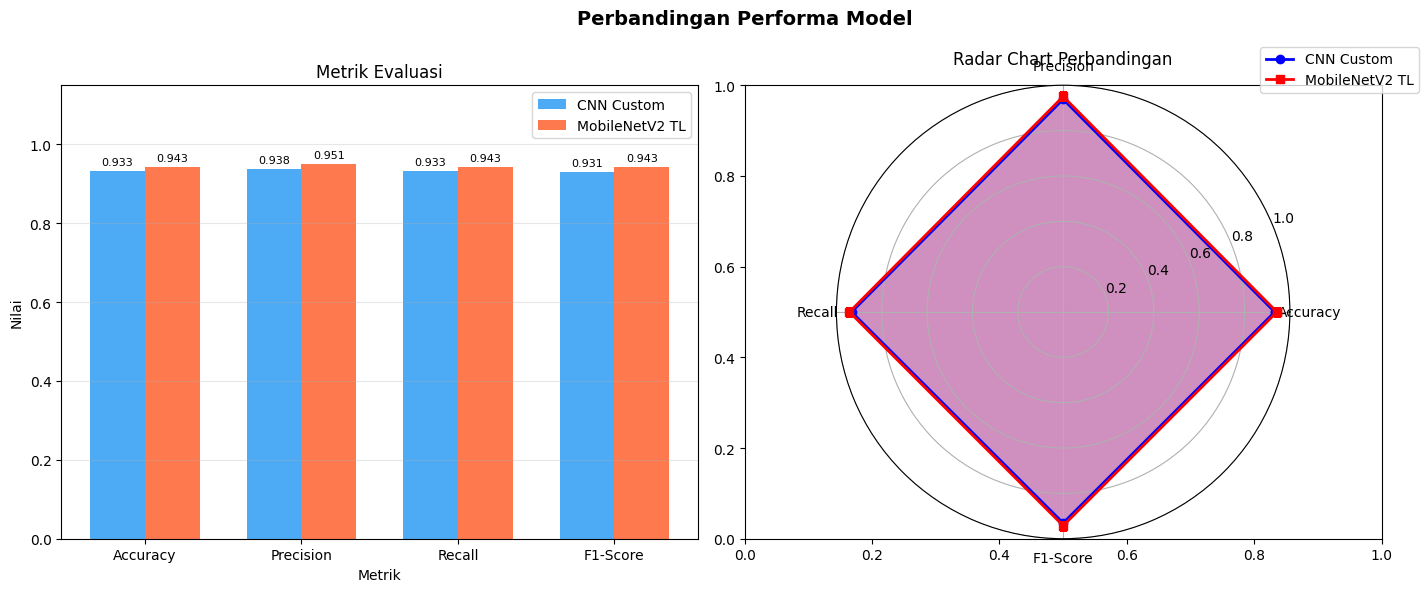

In [ ]:
# Visualisasi perbandingan
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
cnn_vals = [acc_cnn, prec_cnn, rec_cnn, f1_cnn]
tl_vals  = [acc_tl, prec_tl, rec_tl, f1_tl]

x = np.arange(len(metrics))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Perbandingan Performa Model', fontsize=14, fontweight='bold')

# Bar chart
bars1 = ax1.bar(x - width/2, cnn_vals, width, label='CNN Custom', color='#2196F3', alpha=0.8)
bars2 = ax1.bar(x + width/2, tl_vals, width, label='MobileNetV2 TL', color='#FF5722', alpha=0.8)
ax1.set_xlabel('Metrik')
ax1.set_ylabel('Nilai')
ax1.set_title('Metrik Evaluasi')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim([0, 1.15])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

# Radar chart
from matplotlib.patches import FancyArrowPatch
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
cnn_vals_r = cnn_vals + cnn_vals[:1]
tl_vals_r  = tl_vals + tl_vals[:1]

ax2 = plt.subplot(122, polar=True)
ax2.plot(angles, cnn_vals_r, 'b-o', linewidth=2, label='CNN Custom')
ax2.fill(angles, cnn_vals_r, alpha=0.25, color='blue')
ax2.plot(angles, tl_vals_r, 'r-s', linewidth=2, label='MobileNetV2 TL')
ax2.fill(angles, tl_vals_r, alpha=0.25, color='red')
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics)
ax2.set_ylim([0, 1])
ax2.set_title('Radar Chart Perbandingan', pad=15)
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔟 Prediksi & Visualisasi Contoh Gambar

Menampilkan prediksi model terbaik: MobileNetV2 TL


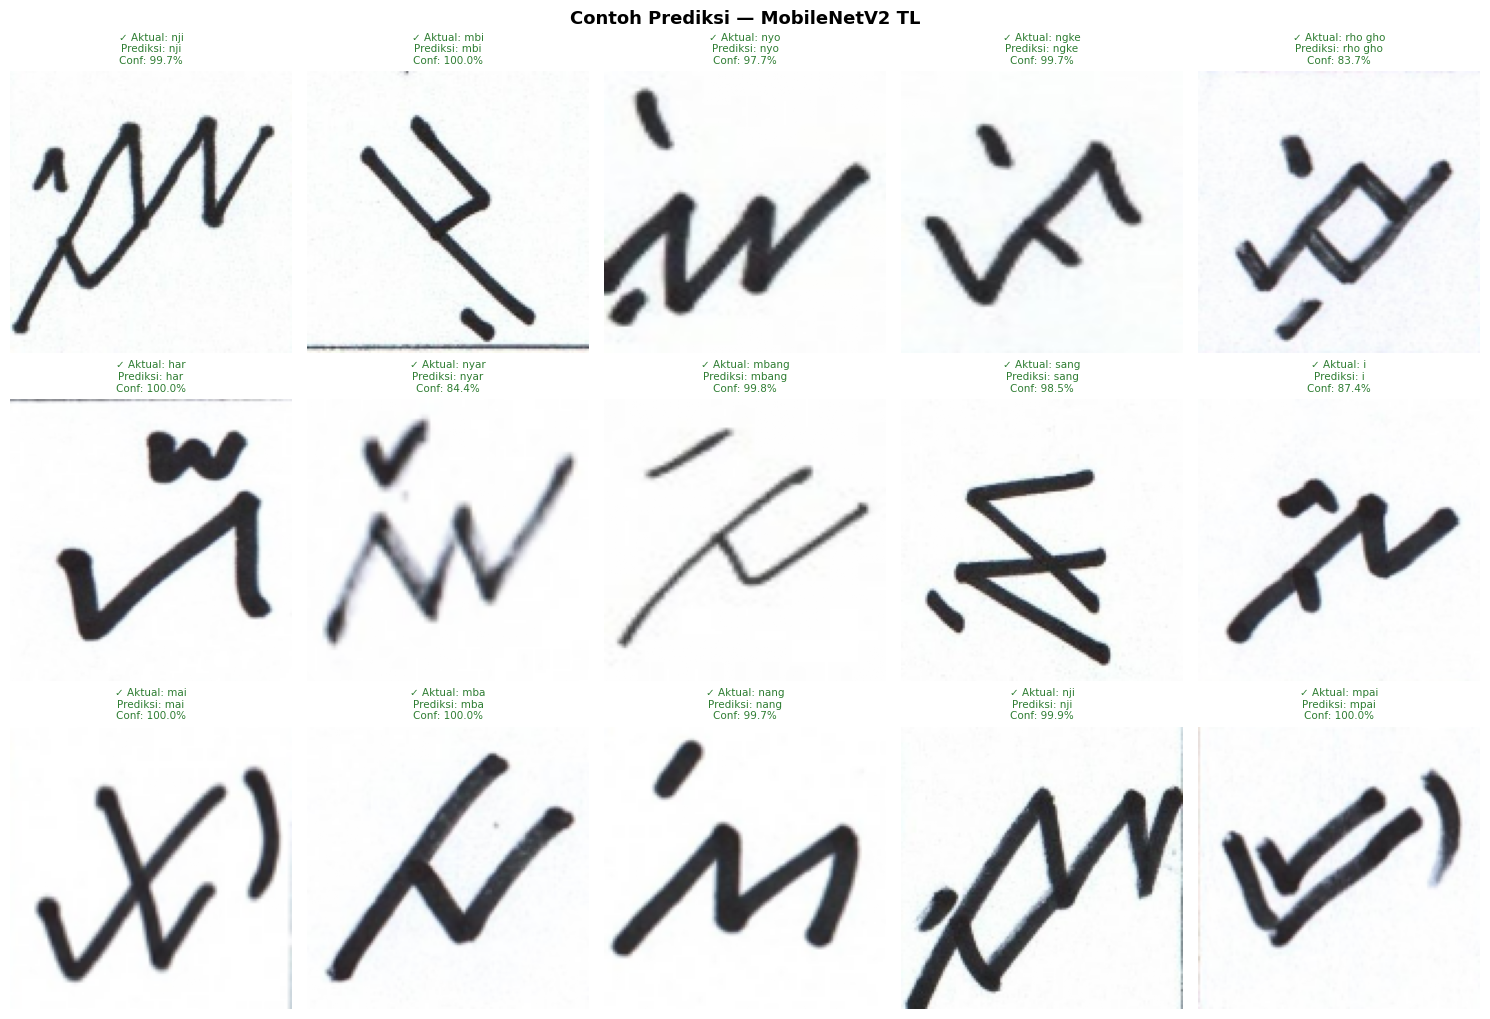

  Akurasi pada sampel ini: 15/15 = 100.0%


In [ ]:
def predict_and_show(model, test_paths, test_labels, class_names, n_show=15, model_name='Model'):
    """Tampilkan prediksi pada beberapa gambar test dengan warna benar/salah"""
    indices = np.random.choice(len(test_paths), n_show, replace=False)

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    fig.suptitle(f'Contoh Prediksi — {model_name}', fontsize=13, fontweight='bold')
    axes = axes.flatten()

    correct, total = 0, 0
    for i, idx in enumerate(indices):
        img_path = test_paths[idx]
        true_lbl = test_labels[idx]

        # Load & preprocess
        img_raw = tf.io.read_file(img_path)
        img     = tf.image.decode_png(img_raw, channels=3)
        img_r   = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) / 255.0
        img_b   = tf.expand_dims(img_r, 0)

        preds    = model.predict(img_b, verbose=0)[0]
        pred_lbl = np.argmax(preds)
        conf     = preds[pred_lbl] * 100

        is_correct = (pred_lbl == true_lbl)
        if is_correct:
            correct += 1
        total += 1

        axes[i].imshow(img_r.numpy())
        color = '#2e7d32' if is_correct else '#c62828'
        mark  = '✓' if is_correct else '✗'
        axes[i].set_title(
            f'{mark} Aktual: {class_names[true_lbl]}\n'
            f'Prediksi: {class_names[pred_lbl]}\n'
            f'Conf: {conf:.1f}%',
            fontsize=7.5,
            color=color
        )
        axes[i].axis('off')

        # Border warna
        for spine in axes[i].spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)

    for j in range(n_show, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.savefig(f'/content/prediksi_{model_name.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Akurasi pada sampel ini: {correct}/{total} = {correct/total*100:.1f}%")

# Tampilkan prediksi model terbaik
best_model = tl_model if acc_tl >= acc_cnn else cnn_model
best_name  = 'MobileNetV2 TL' if acc_tl >= acc_cnn else 'CNN Custom'

print(f"Menampilkan prediksi model terbaik: {best_name}")
predict_and_show(best_model, X_test, y_test, class_names, n_show=15, model_name=best_name)

## 1️⃣1️⃣ Simpan Model & Hasil ke Google Drive

In [ ]:
import json
from datetime import datetime

# Buat folder output di Drive
output_dir = '/content/drive/MyDrive/COMPUTER VISION/hasil_kaganga'
os.makedirs(output_dir, exist_ok=True)

# Simpan model
cnn_model.save(os.path.join(output_dir, 'model_cnn_custom.h5'))
tl_model.save(os.path.join(output_dir, 'model_mobilenetv2_tl.h5'))
print("✅ Model disimpan ke Google Drive")

# Simpan hasil evaluasi ke JSON
results = {
    'timestamp': datetime.now().isoformat(),
    'dataset': {
        'name': 'dataset komering ulu',
        'total_images': TOTAL_IMAGES,
        'num_classes': NUM_CLASSES,
        'class_names': class_names,
        'class_distribution': class_counts,
        'train_size': len(X_train),
        'val_size': len(X_val),
        'test_size': len(X_test)
    },
    'config': {
        'img_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'epochs_cnn': EPOCHS_CNN,
        'epochs_tl': EPOCHS_TL
    },
    'results': {
        'cnn_custom': {
            'accuracy': float(acc_cnn),
            'precision': float(prec_cnn),
            'recall': float(rec_cnn),
            'f1_score': float(f1_cnn)
        },
        'mobilenetv2_tl': {
            'accuracy': float(acc_tl),
            'precision': float(prec_tl),
            'recall': float(rec_tl),
            'f1_score': float(f1_tl)
        }
    },
    'best_model': best_name
}

json_path = os.path.join(output_dir, 'hasil_evaluasi.json')
with open(json_path, 'w') as f:
    json.dump(results, f, indent=2)

# Salin grafik-grafik ke Drive
import shutil
for img_name in ['distribusi_dataset.png', 'sampel_dataset.png', 'augmentasi.png',
                  'training_cnn.png', 'training_tl.png', 'cm_cnn.png', 'cm_tl.png',
                  'perbandingan_model.png']:
    src = f'/content/{img_name}'
    if os.path.exists(src):
        shutil.copy(src, os.path.join(output_dir, img_name))

print(f"\n📁 Semua hasil disimpan di: {output_dir}")
print("   Isi folder:")
for f in sorted(os.listdir(output_dir)):
    print(f"   - {f}")

✅ Model disimpan ke Google Drive

📁 Semua hasil disimpan di: /content/drive/MyDrive/COMPUTER VISION/hasil_kaganga
   Isi folder:
   - augmentasi.png
   - cm_cnn.png
   - cm_tl.png
   - distribusi_dataset.png
   - hasil_evaluasi.json
   - model_cnn_custom.h5
   - model_mobilenetv2_tl.h5
   - perbandingan_model.png
   - sampel_dataset.png
   - training_cnn.png
   - training_tl.png


## ✅ Ringkasan Akhir

In [ ]:
print("""╔══════════════════════════════════════════════════════════════╗
║         RINGKASAN HASIL — DETEKSI AKSARA KAGANGA             ║
║              Dataset: Komering Ulu                           ║
╠══════════════════════════════════════════════════════════════╣""")
print(f"║  Dataset:                                                    ║")
print(f"║    Total Gambar  : {TOTAL_IMAGES:<4} gambar                             ║")
print(f"║    Jumlah Kelas  : {NUM_CLASSES:<4} aksara                             ║")
print(f"║    Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}                            ║")
print(f"╠══════════════════════════════════════════════════════════════╣")
print(f"║  Model 1 — CNN Custom:                                       ║")
print(f"║    Accuracy  : {acc_cnn*100:.2f}%                                    ║")
print(f"║    Precision : {prec_cnn*100:.2f}%                                    ║")
print(f"║    Recall    : {rec_cnn*100:.2f}%                                    ║")
print(f"║    F1-Score  : {f1_cnn*100:.2f}%                                    ║")
print(f"╠══════════════════════════════════════════════════════════════╣")
print(f"║  Model 2 — MobileNetV2 (Transfer Learning):                  ║")
print(f"║    Accuracy  : {acc_tl*100:.2f}%                                    ║")
print(f"║    Precision : {prec_tl*100:.2f}%                                    ║")
print(f"║    Recall    : {rec_tl*100:.2f}%                                    ║")
print(f"║    F1-Score  : {f1_tl*100:.2f}%                                    ║")
print(f"╠══════════════════════════════════════════════════════════════╣")
print(f"║  🏆 Model Terbaik: {best_name:<43}║")
print(f"╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║         RINGKASAN HASIL — DETEKSI AKSARA KAGANGA             ║
║              Dataset: Komering Ulu                           ║
╠══════════════════════════════════════════════════════════════╣
║  Dataset:                                                    ║
║    Total Gambar  : 21150 gambar                             ║
║    Jumlah Kelas  : 336  aksara                             ║
║    Train/Val/Test: 14804/3173/3173                            ║
╠══════════════════════════════════════════════════════════════╣
║  Model 1 — CNN Custom:                                       ║
║    Accuracy  : 93.32%                                    ║
║    Precision : 93.83%                                    ║
║    Recall    : 93.32%                                    ║
║    F1-Score  : 93.07%                                    ║
╠══════════════════════════════════════════════════════════════╣
║  Model 2 — MobileNetV2 (Transfer Learning